In [1]:
import os
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pytorch_lightning import seed_everything
from rdkit import Chem
from torch_geometric.data import Batch, DataLoader
from tqdm import tqdm

from sigmadock.config import get_experiment_config
from sigmadock.data import SigmaDataset
from sigmadock.datafronts import MetaFront
from sigmadock.geo.viz import plot_interaction_graph_3d_plotly
from sigmadock.torch_utils.utils import re_batch_with_attrs
from sigmadock.oracle import HPARAMS

# Prefer env; see notebooks/README.md
DATA_DIR = Path(os.environ.get("SIGMADOCK_DATA_DIR", "../../data")).resolve()
CKPT_PATH = Path(os.environ.get("SIGMADOCK_CKPT_DIR", "../../checkpoints/sample_checkpoint_0.ckpt")).resolve()

# Sampling & Reverse Generation (extension of 04)

**Extension** of **04_forward_diffusion.ipynb**: full large-batch multi-seed sampling, PoseBusters checks, and top-k heuristics. More seeds, config options, and analysis than the compact version in 04.

### Setup Data & Loaders

In [ ]:
SEED = 123

seed_everything(SEED)
config = get_experiment_config(
    experiment="posebusters",
    root_dir=DATA_DIR,
)
test_datafront = MetaFront([config])

# Prune out data from blacklist.
def load_pdbs_from_txt(txt_path: Path) -> list[str]:
    """Load PDB IDs from a text file."""
    with open(txt_path) as f:
        pdb_ids = [line.strip() for line in f if line.strip()]
    return pdb_ids

# NOTE only for PoseBusters
if config.name == "posebusters":
    selected_ids = load_pdbs_from_txt(
        DATA_DIR / "posebusters_paper/posebusters_pdb_ccd_ids.txt",
    )
    test_datafront.prune_pairs_with_ids(selected_ids)

dataset = SigmaDataset(
    datafront=test_datafront,
    pb_check=False,
    force_alignment=False,
    alignment_tries=0,
    # Distances
    pocket_distance_cutoff=6.0,
    pocket_com_noise=0.5,
    pocket_distance_noise=0.5,
    # Misc
    get_mol_info=True,
    force_retry=False,
    seed=SEED,
    verbose=True,
    # Inference Mode
    sample_conformer=False, # Set to True if you want to sample a new conformer from scratch (different fragment local coords from ref).
    skip_bounds_check=True,
    random_rotation=False,
)

[rank: 0] Seed set to 123


Pruned pairs to 308/428 using provided IDs.


### Load Large Batch


In [3]:
seed_everything(SEED, workers=True)

dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=8,
)

# Whatever your GPU can handle / however many you want to test!
MAX_BATCH_SIZE = min(64, len(dataset))
single_datas = []
for i, batch in tqdm(enumerate(dataloader)):
    single_datas += [batch[i] for i in range(batch.num_graphs)]
    if len(single_datas) >= MAX_BATCH_SIZE:
        break

batch = Batch.from_data_list(single_datas)

[rank: 0] Seed set to 123
0it [00:00, ?it/s]

[WARN] Using random minimal fragmentation for Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@](=O)(O)O[P@](=O)(O)OC[C@H]2O[C@@H](O)[C@H](OC(=O)c3ccccc3)[C@@H]2O)[C@@H](O)[C@H]1O. Too many torsional bonds.
[WARN] Using random minimal fragmentation for CCCC[C@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O. Too many torsional bonds.


8it [00:01,  9.42it/s]

[WARN] Using random minimal fragmentation for CC(C)C(=O)Nc1ncc(C(=O)NCCN(Cc2ccccc2)C(=O)c2ccc(S(=O)(=O)Nc3ccccc3)cc2)s1. Too many torsional bonds.


23it [00:02, 10.89it/s]

[WARN] Using random minimal fragmentation for CCCCCCCCCCCCCCCCC. Too many torsional bonds.
[WARN] Using random minimal fragmentation for CCCCOc1ccc(C[C@H](CC)C(=O)O)cc1CNC(=O)c1ccc(C(F)(F)F)cc1F. Too many torsional bonds.
[WARN] Using random minimal fragmentation for CC(C)(CO[P@@](=O)(O)O[P@](=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O)[C@@H](O)C(=O)NCCC(=O)NCCSC(=O)c1ccccc1. Too many torsional bonds.


51it [00:05,  6.52it/s]

[WARN] Using random minimal fragmentation for CCNC(=O)CCNC(=O)[C@H](O)C(C)(C)CO[P@@](=O)(O)O[P@@](=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O. Too many torsional bonds.


63it [00:06,  9.62it/s]


### Example

In [4]:
# 10 # Has a fragmentation issue - why is it not fragmenting?
# 12 # Has a bunch of nodes that are not marked overconstrained
dp = dataset[
             20
             ]
_ = plot_interaction_graph_3d_plotly(
    dp,
    pos_key="ref_pos",
    pocket_com="pocket_com",
    show_protein=True,
    show_protein_virtual=True,
    show_ligand_virtual=False,
    show_overconstrained=False,
    show_triangulation=True,
    show_interaction_edges=True,
    show_protein_virtual_edges=False,
    show_ligand_virtual_edges=False,
    show_protein_ligand_virtual_edges=True,
    com_radius=1,
)

## Load Model

In [5]:
from sigmadock.trainer import SigmaLightningModule
from sigmadock.utils import load_from_scratch

model: SigmaLightningModule = load_from_scratch(
    CKPT_PATH,
    load_ema=True,
    strict=True,
    enforced_cfg={
        "cache_path": "../.cache_igso3",
        }
)

# Use the EMA model for inference
ema_model = model.ema_model
ema_model.eval()
ema_model.to("cuda")

# Set device fully for SO3 Diffuser
device = next(ema_model.model.parameters()).device
ema_model.model.diffuser._so3_diffuser.set_device(device)

print(
    ema_model.model.model.use_esm_embeddings,
    ema_model.model.include_interactions,
    ema_model.model.rot_score_method,
    ema_model.model.rot_score_scaling,
    dataset.ignore_conjugated_torsion,
)

Error loading checkpoint with torch.load: No module named 'alphadock'. Attempting load with legacy module alias.
[WARNING] Using provided HPARAMS that could be modified from oracle.py
[WARN] Ignored kwargs in EquiformerV2: {'cache_path': '../.cache_igso3'}. Please check for typos unless unintended.
[INFO] DIST | Skipping inter_fragments edges as ligand_ligand_interactions is False
Using cached IGSO3 in ../.cache_igso3/eps_1000_omega_2000_min_sigma_0_1_max_sigma_1_5_schedule_logarithmic
Successfully loaded EMA model.
False True space rms False


# Eval Losses 

[rank: 0] Seed set to 123
100%|██████████| 16/16 [00:16<00:00,  1.05s/it]


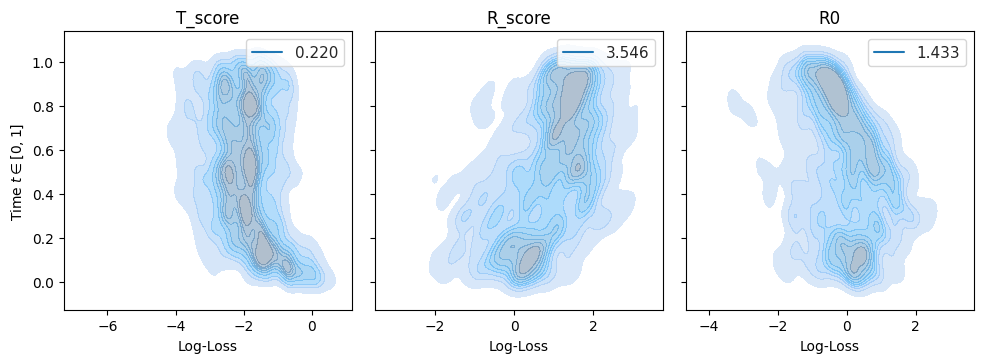

In [6]:
seed_everything(SEED)

times = []
all_losses = []
cp_batch = deepcopy(batch.to(ema_model.device))

with torch.no_grad():
    for i in tqdm(range(16)):
        outputs, losses = ema_model(cp_batch)
        times.append(outputs["t"])
        all_losses.append(losses)
total_losses = {k: torch.cat([l[k] for l in all_losses]) for k in all_losses[0]}

# Prepare data
times = torch.cat(times).cpu()
T_scores = torch.cat([l["T_score"] for l in all_losses]).cpu()
R_scores = torch.cat([l["R_score"] for l in all_losses]).cpu()
R0_scores = torch.cat([l["R0"] for l in all_losses]).cpu()

loss_dict = {k: v.mean().item() for k, v in total_losses.items()}

# Subplots: 1 row (3 columns), share y-axis (time)
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
sns.set(style="whitegrid", palette="colorblind")

# KDEs with time on y-axis, losses on x-axis
sns.kdeplot(x=torch.log(T_scores), y=times, fill=True, alpha=0.4, bw_adjust=0.5, ax=axes[0])
axes[0].set_title("T_score")
axes[0].set_xlabel("Log-Loss")
axes[0].set_ylabel("Time $t \\in [0,1]$")
axes[0].plot([], [], label=f"{loss_dict['T_score']:.3f}")
axes[0].legend()

sns.kdeplot(x=torch.log(R_scores), y=times, fill=True, alpha=0.4, bw_adjust=0.5, ax=axes[1])
axes[1].set_title("R_score")
axes[1].set_xlabel("Log-Loss")
axes[1].plot([], [], label=f"{loss_dict['R_score']:.3f}")
axes[1].legend()

sns.kdeplot(x=torch.log(R0_scores), y=times, fill=True, alpha=0.4, bw_adjust=0.5, ax=axes[2])
axes[2].set_title("R0")
axes[2].set_xlabel("Log-Loss")
axes[2].plot([], [], label=f"{loss_dict['R0']:.3f}")
axes[2].legend()

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.legend()
plt.show()

# Reverse Generation

In [7]:
from copy import deepcopy

import numpy as np
from pytorch_lightning import seed_everything
from tqdm import tqdm

from sigmadock.diff.sampling import sample_notebook
from sigmadock.oracle import HPARAMS

cur_seed = 123
num_samples = 5
seed_everything(cur_seed, workers=True, verbose=False)
seeds = np.random.randint(0, 1000, size=num_samples).tolist()
all_outputs = []
for i, seed in enumerate(seeds):
    # TODO for each seed also generate a different conformer! This is done in the sample.py script.
    tmp = sample_notebook(
        denoiser=ema_model.model,
        batch=deepcopy(batch),
        # Discretization
        t_min=2e-3,
        num_steps=30,
        discretization="edm",
        rho=3,
        # ODE Solver & Noise
        solver="euler",
        noise_scale=0,  # At the beginning of the reverse sampling, decays according to **(1/noise_decay).
        noise_decay=1,
        # Misc
        seed=seed,
        use_true_scores=False,
        verbose=i == 0,
    )
    all_outputs.append(tmp)

Using 30 steps for reverse sampling with: 
             seed=510 
             rho=3 
             solver=euler 
             noise_scale=0 
             t_min=0.002 
             


29it [00:26,  1.10it/s]
29it [00:26,  1.10it/s]
29it [00:26,  1.09it/s]
29it [00:26,  1.09it/s]
29it [00:26,  1.10it/s]


# Top-K RMSD & PoseBusters

### Run PoseBusters

In [ ]:
import pandas as pd
import posebusters
import spyrmsd
import spyrmsd.molecule
import spyrmsd.rmsd
from rdkit.Geometry import Point3D

# TODO parallelize this part, too slow with 1 CPU!
pbc = posebusters.PoseBusters(
    config="redock",
    max_workers=0,
)

PB_BUST = True

all_rmsds = []
all_pb_checks = []
for idx in tqdm(range(len(all_outputs[0][0]))):
    s_rmsds = []
    pb_checks = []
    for seed_idx in range(len(all_outputs)):
        # SLOW
        # mol_ref = deepcopy(sample.mol_info["original"])
        # sample_batch = deepcopy(all_outputs[seed_idx][0])

        sample_batch = all_outputs[seed_idx][0]
        sample = re_batch_with_attrs(sample_batch, ["pos_t", "pos_0"])[idx]
        mol_ref = sample.mol_info["original"]
        # NOTE comparing to non-aligned original pose instead of "aligned". Could compare to "aligned for fairness too"
        # NOTE aligned is also relaxed so it's good!!!

        pred_coords = sample.pos_t * HPARAMS.general.dimensional_scale + sample.pocket_com
        ref_coords = sample.pos_0 * HPARAMS.general.dimensional_scale + sample.pocket_com
        # Get only atoms (not virtual or dummies)
        is_lig = (sample.frag_atom_idx != -1) & (sample.node_entity <= 1)
        pred_lig_coords = pred_coords[is_lig]
        ref_lig_coords = ref_coords[is_lig]
        mol = Chem.RWMol(mol_ref)
        mol.RemoveAllConformers()
        conf = Chem.Conformer(mol.GetNumAtoms())
        for i, (x, y, z) in enumerate(pred_lig_coords.tolist()):
            conf.SetAtomPosition(i, Point3D(x, y, z))
        _ = mol.AddConformer(conf, assignId=True)

        # Convert to spyrmsd molecule if only computing RMSD, else leave PoseBusters checks
        smol = spyrmsd.molecule.Molecule.from_rdkit(mol)
        rmol = spyrmsd.molecule.Molecule.from_rdkit(mol_ref)
        # r_rmsd = spyrmsd.rmsd.rmsd(smol.coordinates, rmol.coordinates, smol.atomicnums, rmol.atomicnums)
        s_rmsd = spyrmsd.rmsd.rmsdwrapper(smol, rmol)[0]
        s_rmsds.append(s_rmsd)

        # PoseBusters Checks (includes sRMSD < 2)
        if PB_BUST:
            df = pbc.bust(
                mol,
                mol_ref,
                sample.mol_info["pocket"],
                full_report=False,
            )
            pb_checks.append(df.copy())

    if PB_BUST:
        all_pb_checks.append(pd.concat(pb_checks))
    all_rmsds.append(s_rmsds)

# Get PoseBusters success rates
if PB_BUST:
    pb_results = pd.concat(
        [
            pd.concat([x.iloc[seed_idx] for x in all_pb_checks], axis=1).mean(axis=1)
            for seed_idx in range(len(all_outputs))
        ],
        axis=1,
    )

# Get top-K metrics
rmsds = np.array(all_rmsds)
top_k_performance = [(rmsds[:, : i + 1] < 2).any(axis=1).mean() for i in range(rmsds.shape[1])]
avg_performance = (rmsds < 2).mean(axis=0).tolist()

# Get overall pb_val
seed_pb_val = []
for seed_idx in range(rmsds.shape[1]):
    seed_results = pd.concat([x.iloc[seed_idx] for x in all_pb_checks], axis=1).transpose()
    pb_val = np.array(seed_results.sum(axis=1) / len(seed_results.columns))
    val_rate = sum(pb_val >= 1) / len(pb_val) 
    seed_pb_val.append(val_rate)

# NOTE avg_performance is across different seeds
top_k_performance, avg_performance, seed_pb_val

([np.float64(0.671875),
  np.float64(0.78125),
  np.float64(0.828125),
  np.float64(0.828125),
  np.float64(0.84375)],
 [0.671875, 0.609375, 0.703125, 0.578125, 0.640625],
 [np.float64(0.515625),
  np.float64(0.4375),
  np.float64(0.546875),
  np.float64(0.515625),
  np.float64(0.46875)])

## Average Performance

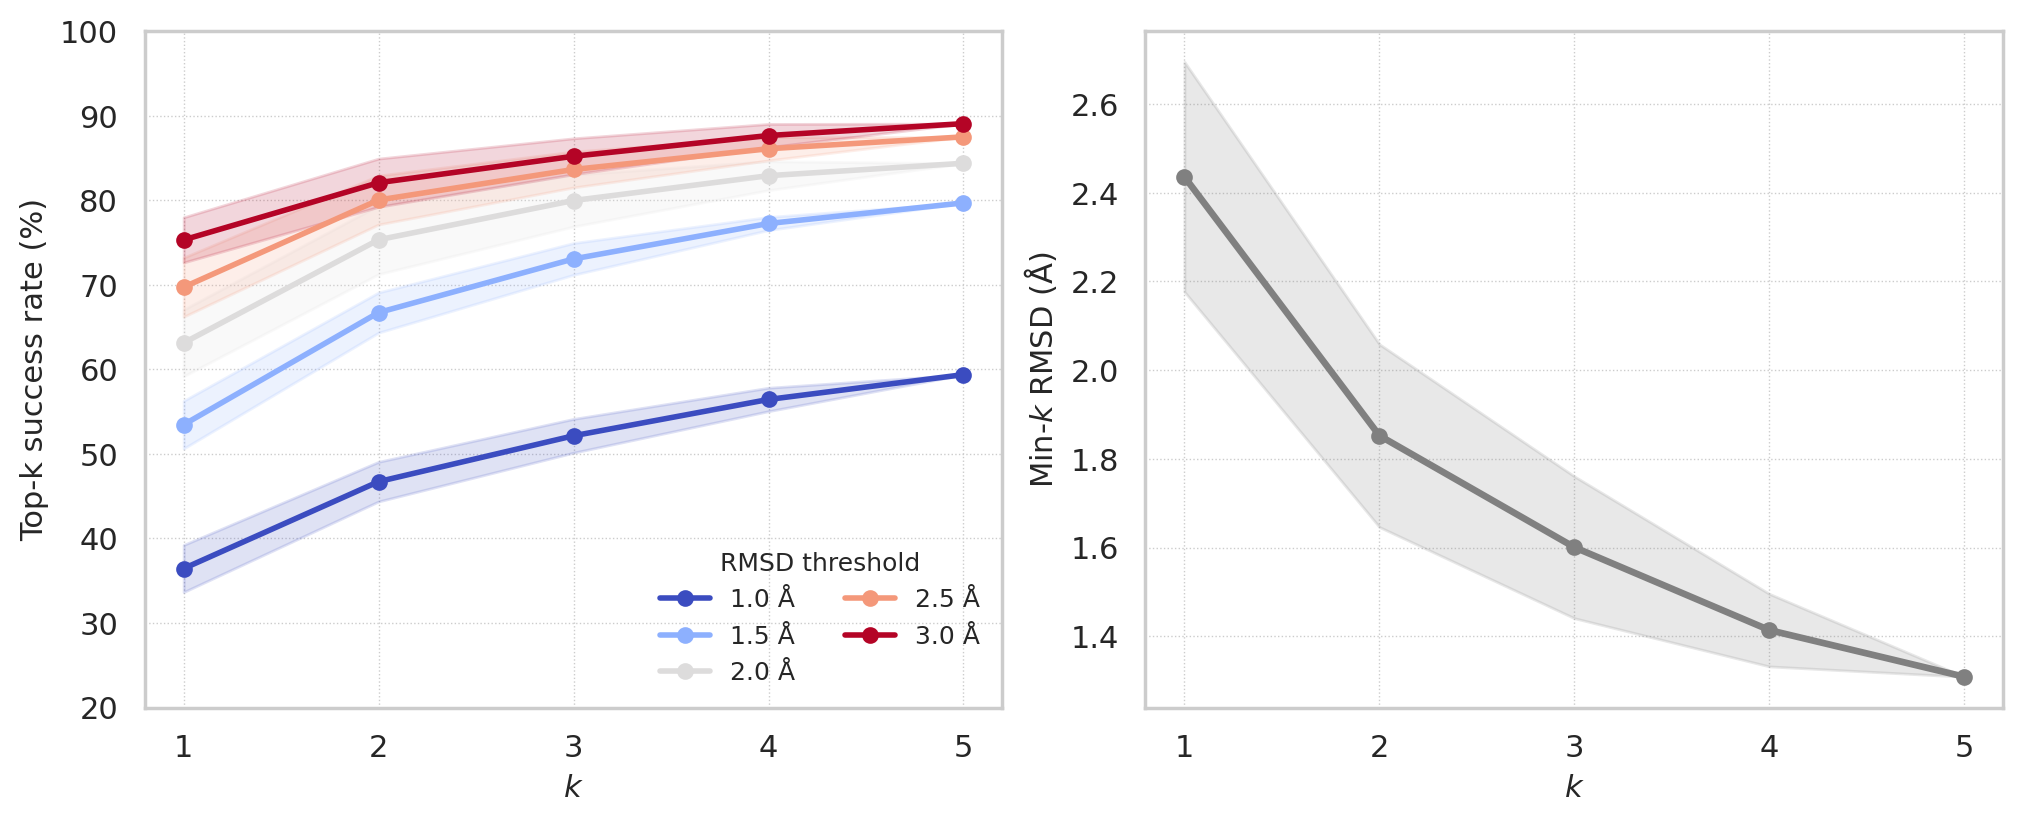

,Top-1.00Å,Top-1.50Å,Top-2.00Å,Top-2.50Å,Top-3.00Å
1,0.364375,0.534531,0.631250,0.697187,0.753125
2,0.467187,0.667188,0.753281,0.800312,0.820781
3,0.521406,0.730625,0.799687,0.836406,0.852031
4,0.564375,0.772500,0.829063,0.860938,0.876563
5,0.593750,0.796875,0.843750,0.875000,0.890625


In [9]:
def permutation_topk_and_mink(rmsds, thresholds=(2.0,), num_permutations=200, ks=None, rng_seed=42):  # noqa: ANN001, ANN201
    """
    Sample permutations and compute:
      - top-k success rates for each k and threshold (mean +- std across permutations)
      - mean(min RMSD) for each k (mean +- std across permutations)
    Defaults: ks = np.arange(1, num_seeds+1) (no skipping).
    Returns stats dict.
    """
    rmsds = np.asarray(rmsds)
    if rmsds.ndim != 2:
        raise ValueError("rmsds must be 2D: (num_molecules, num_seeds)")
    num_molecules, num_seeds = rmsds.shape
    thresholds = np.asarray(thresholds, dtype=float)
    rng = np.random.default_rng(rng_seed)

    if ks is None:
        ks = np.arange(1, num_seeds + 1, dtype=int)  # <- changed: include every k
    else:
        ks = np.asarray([k for k in ks if 1 <= k <= num_seeds], dtype=int)
    K = len(ks)
    T = len(thresholds)
    P = int(num_permutations)

    raw_success = np.zeros((P, K, T), dtype=float)
    raw_mean_min = np.zeros((P, K), dtype=float)

    for p in range(P):
        perm = rng.permutation(num_seeds)
        for ki, k in enumerate(ks):
            mins = np.min(rmsds[:, perm[:k]], axis=1)  # per-molecule min over first k seeds
            raw_success[p, ki, :] = np.mean(mins[:, None] < thresholds[None, :], axis=0)
            raw_mean_min[p, ki] = mins.mean()

    mean_success = raw_success.mean(axis=0)  # K x T
    std_success = raw_success.std(axis=0, ddof=0)
    mean_min = raw_mean_min.mean(axis=0)  # K
    std_min = raw_mean_min.std(axis=0, ddof=0)

    stats = {
        "thresholds": thresholds,
        "ks": ks,
        "raw_success": raw_success,
        "mean_success": mean_success,
        "std_success": std_success,
        "raw_mean_min": raw_mean_min,
        "mean_min": mean_min,
        "std_min": std_min,
        "num_permutations": P,
        "num_molecules": num_molecules,
        "num_seeds": num_seeds,
    }
    return stats


def heuristic_topk_and_mink(post_top_k, post_min_k, thresholds=(2.0,), ks=None):  # noqa: ANN001, ANN201
    """
    Build a 'stats' dict (same format as permutation_topk_and_mink) from
    heuristic-sorted results.

    post_top_k : list of arrays [num_molecules x num_seeds], each bool (success per k)
    post_min_k : list of arrays [num_molecules x num_seeds], each float (min RMSD per k)
    thresholds : thresholds used (for consistency with plotting)
    ks         : optional subset of k values
    """
    post_top_k_arr = np.array(post_top_k)  # (num_molecules, num_seeds)
    post_min_k_arr = np.array(post_min_k)  # (num_molecules, num_seeds)
    num_molecules, num_seeds = post_top_k_arr.shape

    ks = np.arange(1, num_seeds + 1) if ks is None else np.asarray([k for k in ks if 1 <= k <= num_seeds], dtype=int)

    thresholds = np.asarray(thresholds, dtype=float)

    # mean/std across molecules
    mean_success = np.zeros((len(ks), len(thresholds)))
    std_success = np.zeros_like(mean_success)

    for ti, thr in enumerate(thresholds):
        # here post_top_k_arr already encodes success for 2Å,
        # but if you want generic thresholds you can rebuild from min RMSD
        success_bool = post_min_k_arr[:, :].reshape(num_molecules, -1, order="C")[:, :num_seeds][:, None, :] < thr
        # simpler: just recompute success from min RMSD
        for ki, k in enumerate(ks):
            mins = post_min_k_arr[:, k - 1]  # min RMSD up to k
            succ = mins < thr
            mean_success[ki, ti] = succ.mean()
            std_success[ki, ti] = succ.std(ddof=0)

    mean_min = post_min_k_arr[:, ks - 1].mean(axis=0)
    std_min = post_min_k_arr[:, ks - 1].std(axis=0, ddof=0)

    stats = {
        "thresholds": thresholds,
        "ks": ks,
        "mean_success": mean_success,
        "std_success": std_success,
        "mean_min": mean_min,
        "std_min": std_min,
        "num_molecules": num_molecules,
        "num_seeds": num_seeds,
    }
    return stats


def top_k_figure(stats, ax, show_bounds=True, cmap_name="turbo", ylim=None) -> None:  # noqa: ANN001
    """
    Plot Top-k success rate (%) vs k with one line per RMSD threshold.

    Parameters
    ----------
    stats : dict
        Output from permutation_topk_and_mink or heuristic_topk_and_mink.
    ax : matplotlib axis
        Axis to plot on.
    show_bounds : bool
        Whether to show +- sigma shading.
    cmap_name : str
        Matplotlib colormap name (default "turbo").
    ylim : tuple(float,float) or None
        y-axis range (min, max). If None, auto.
    """
    ks = stats["ks"]
    thresholds = stats["thresholds"]
    mean_success = stats["mean_success"]
    std_success = stats["std_success"]

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i) for i in np.linspace(0, 1, len(thresholds))]

    for ti, t in enumerate(thresholds):
        m = mean_success[:, ti] * 100
        s = std_success[:, ti] * 100
        ax.plot(ks, m, label=f"{t:.1f} Å", linewidth=2.0, marker="o", markersize=5, color=colors[ti])
        if show_bounds:
            ax.fill_between(ks, m - s, m + s, alpha=0.16, color=colors[ti])

    ax.set_xlabel("$k$", fontsize=11)
    ax.set_ylabel("Top-k success rate (%)", fontsize=11)
    ax.set_xticks(ks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle=":", linewidth=0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(title="RMSD threshold", fontsize=9, title_fontsize=9, frameon=False, ncol=2)


def delta_k_figure(stats, ax, show_bounds=True, ylim=None) -> None:  # noqa: ANN001
    """
    Plot mean min RMSD vs k with optional ±1σ shading.

    Parameters
    ----------
    stats : dict
        Output from permutation_topk_and_mink or heuristic_topk_and_mink.
    ax : matplotlib axis
        Axis to plot on.
    show_bounds : bool
        Whether to show ±1σ shading.
    ylim : tuple(float,float) or None
        y-axis range (min, max). If None, auto.
    """
    ks = stats["ks"]
    mean_min = stats["mean_min"]
    std_min = stats["std_min"]

    ax.plot(ks, mean_min, linewidth=2.4, marker="o", markersize=5, color="gray")
    if show_bounds:
        # Remove outliers for shading
        iqr = np.percentile(mean_min, 75) - np.percentile(mean_min, 25)
        # upper_bound = np.percentile(mean_min, 75) + 1.5
        q1_ = np.percentile(mean_min, 25) - 1.5 * iqr
        q3_ = np.percentile(mean_min, 75) + 1.5 * iqr
        std_min = np.clip(std_min, a_min=None, a_max=(q3_ - q1_) / 2)
        max_bound = mean_min + std_min
        min_bound = mean_min - std_min
        min_bound[min_bound <0] = 0
        ax.fill_between(ks, min_bound, max_bound, alpha=0.18, color="gray")

    ax.set_xlabel("$k$", fontsize=11)
    ax.set_ylabel("Min-$k$ RMSD (Å)", fontsize=11)
    ax.set_xticks(ks)
    ax.grid(True, linestyle=":", linewidth=0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)


# Get stats
thresholds = [1.0, 1.5, 2, 2.5, 3]
stats = permutation_topk_and_mink(rmsds, thresholds=thresholds, num_permutations=100, ks=None, rng_seed=1)

# Plot params
show_bounds = True
save_prefix = None

figsize = (10, 4)
fig, axs = plt.subplots(1, 2, figsize=figsize, dpi=200, constrained_layout=True)
top_k_figure(stats, axs[0], ylim=(20, 100), cmap_name="coolwarm")
delta_k_figure(stats, axs[1])
if save_prefix is not None:
    outp = Path(save_prefix)
    fig.savefig(str(outp.with_suffix(".png")), dpi=300, bbox_inches="tight")
    fig.savefig(str(outp.with_suffix(".pdf")), dpi=300, bbox_inches="tight")
plt.show()

average_df = pd.DataFrame(
    stats["mean_success"], index=stats["ks"], columns=[f"Top-{t:.2f}Å" for t in stats["thresholds"]]
)
# Could also add PB Validity into the plot.
average_df

### HeuriStics | PB-Val Selector (Blind to Bound Pose)

[rank: 0] Seed set to 1


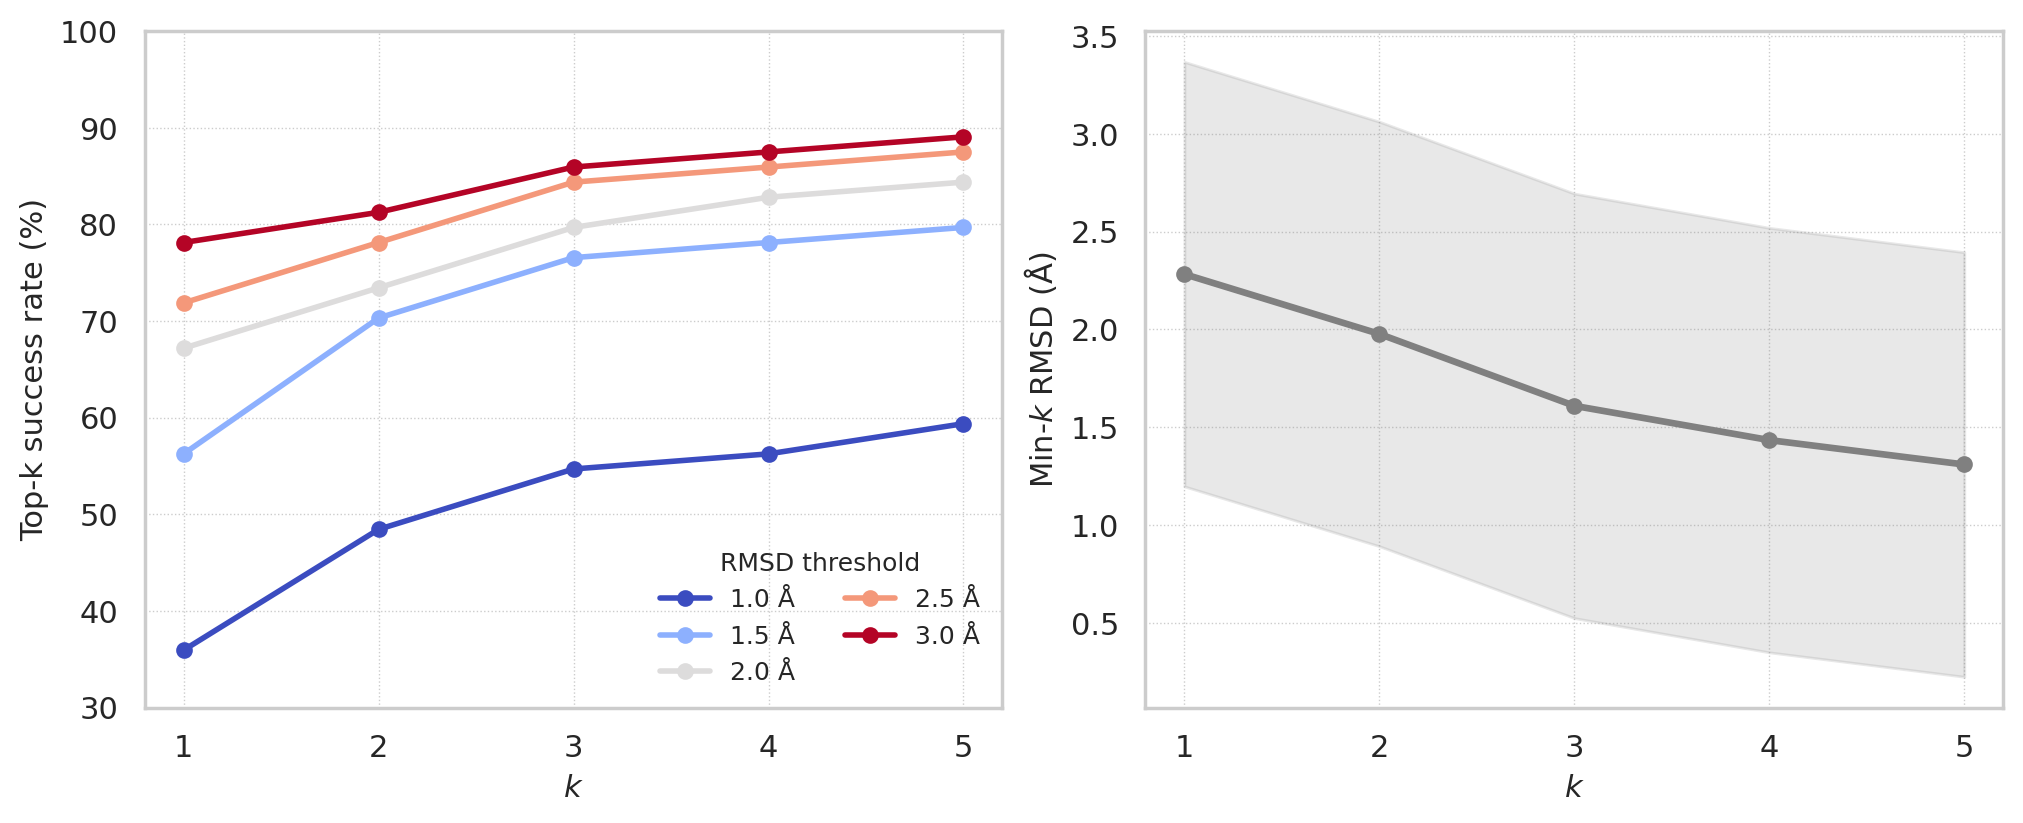

,Top-1.00Å,Top-1.50Å,Top-2.00Å,Top-2.50Å,Top-3.00Å
1,0.359375,0.562500,0.671875,0.718750,0.781250
2,0.484375,0.703125,0.734375,0.781250,0.812500
3,0.546875,0.765625,0.796875,0.843750,0.859375
4,0.562500,0.781250,0.828125,0.859375,0.875000
5,0.593750,0.796875,0.843750,0.875000,0.890625


In [10]:
postprocessing_checks = [
    "minimum_distance_to_protein",
    "tetrahedral_chirality",
    "internal_energy",
    "internal_steric_clash",
    "double_bond_flatness",
    "bond_lengths",
    "bond_angles",
]

seed_everything(1)
# This is here because our heuristic is non-deterministic due to tie-breaking
# Add some noise to the scores to break ties randomly
stochasticity_max = 0.01

post_rmsds = []
scores_pb_checks = []
post_valid_pb_checks = []
for idx in range(len(all_pb_checks)):
    pb_mol = all_pb_checks[idx]
    pb_mol.get(postprocessing_checks).mean()
    per_seed_checks = pb_mol.get(postprocessing_checks)
    # Currently score is the mean per_seed_checks
    scores = np.array(per_seed_checks.mean(1).array)
    scores_pb_checks.append(np.array(per_seed_checks.mean(1).array))
    post_is_valid = np.array((per_seed_checks.mean(1) == 1).array)
    post_valid_pb_checks.append(pb_mol[post_is_valid])
    post_rmsds.append(np.array(all_rmsds)[idx][post_is_valid])

# Get average top-k & sorted by score
post_pb_checks = []
post_top_k = []
post_min_k = []
for idx in range(len(all_pb_checks)):
    score = deepcopy(scores_pb_checks[idx])
    # Add stochasticity
    score += np.random.normal(0, stochasticity_max, size=score.shape)
    descending_score_idxs = score.argsort()[-1::-1]
    sorted_per_mol_rmsds = np.array([all_rmsds[idx][a] for a in descending_score_idxs])
    post_pb_checks.append(all_pb_checks[idx].iloc[descending_score_idxs])
    post_top_k.append([(sorted_per_mol_rmsds[: i + 1] < 2).any() for i in range(len(sorted_per_mol_rmsds))])
    post_min_k.append([sorted_per_mol_rmsds[: i + 1].min() for i in range(len(sorted_per_mol_rmsds))])

# Collect Heuristic stats
heur_stats = heuristic_topk_and_mink(post_top_k, post_min_k, thresholds=[1, 1.5, 2, 2.5, 3])

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=200, constrained_layout=True)
top_k_figure(heur_stats, axs[0], show_bounds=False, ylim=(30, 100), cmap_name="coolwarm")
delta_k_figure(heur_stats, axs[1], show_bounds=True)
plt.show()

heuristics_df = pd.DataFrame(
    heur_stats["mean_success"], index=heur_stats["ks"], columns=[f"Top-{t:.2f}Å" for t in heur_stats["thresholds"]]
)
# Could also add PB Validity into the plot
heuristics_df

PB-Validity

In [25]:
top_1_result = pd.concat([x.iloc[0] for x in post_pb_checks], axis=1).transpose()

pb_val = np.array(top_1_result.sum(axis=1) / len(top_1_result.columns))
# Ratio of molecules generated that pass all PB Checks (includes RMSD < 2)
print(f"RMSD < 2: {top_1_result['rmsd_≤_2å'].mean(axis=0)}")
print(f"RMSD < 2 & PB-Valid: {sum(pb_val == 1) / len(pb_val)}")

top_1_result.transpose().mean(axis=1)

RMSD < 2: 0.671875
RMSD < 2 & PB-Valid: 0.640625


mol_pred_loaded                            1.000000
mol_true_loaded                            1.000000
mol_cond_loaded                            1.000000
sanitization                               1.000000
inchi_convertible                          1.000000
all_atoms_connected                        1.000000
no_radicals                                1.000000
molecular_formula                          1.000000
molecular_bonds                            1.000000
double_bond_stereochemistry                1.000000
tetrahedral_chirality                      0.984375
bond_lengths                               0.984375
bond_angles                                0.937500
internal_steric_clash                      0.984375
aromatic_ring_flatness                     1.000000
non-aromatic_ring_non-flatness             1.000000
double_bond_flatness                       1.000000
internal_energy                            1.000000
protein-ligand_maximum_distance            1.000000
minimum_dist

## Viz Generated Samples

In [26]:
np.where(~seed_results["internal_steric_clash"] & seed_results["rmsd_≤_2å"])[0]
np.where(~seed_results["tetrahedral_chirality"] & seed_results["rmsd_≤_2å"])[0]
np.where(~seed_results["minimum_distance_to_protein"] & seed_results["rmsd_≤_2å"])[0]
np.where(~seed_results["internal_energy"] & seed_results["rmsd_≤_2å"])[0]
np.where(~seed_results["bond_lengths"] & seed_results["rmsd_≤_2å"])[0]

array([ 5,  9, 13])

In [33]:
import ipywidgets as widgets
import plotly.graph_objs as go
from IPython.display import display

from sigmadock.geo.viz import plot_interaction_graph_3d_plotly

STEP = -1
BATCH_IDX = 0
SEED_IDX = 1 # Index of the seed to evaluate

sample_batch, sample_pos, sample_edges = all_outputs[SEED_IDX][0], all_outputs[SEED_IDX][1], all_outputs[SEED_IDX][2]
sample_batch.pos_t = torch.Tensor(sample_pos[STEP])
batch_out = re_batch_with_attrs(sample_batch, ["pos_t", "pos_0"])

print(scores_pb_checks[BATCH_IDX])
print(all_rmsds[BATCH_IDX])
print(sample_batch[BATCH_IDX].mol_info['pdb_path'].stem)
print(all_rmsds[BATCH_IDX][SEED_IDX])

# Use the widget to interactively get camera angle for consistent views
fw = None
fw = go.FigureWidget()
plot_interaction_graph_3d_plotly(
    batch_out[BATCH_IDX].cpu(),
    # pos_key="pos_0",
    pos_key="pos_t",
    ref_pos_key="pos_0",
    show_protein=True,
    show_protein_virtual=True,
    show_ligand_virtual=False,
    show_overconstrained=False,
    show_triangulation=False,
    show_interaction_edges=False,
    fig=fw,
    camera_angle=None,
    # NOTE: Pass in camera angle dict from the widget output!
#     camera_angle={
#     'center': {'x': 0.026602518366833573, 'y': -0.003098229869620955, 'z': -0.002541554872272733},
#     'eye': {'x': 1.2570707748173404, 'y': 0.2565816578923856, 'z': -0.14662548450788973},
#     'projection': {'type': 'perspective'},
#     'up': {'x': -0.15095953642910243, 'y': 0.17552988268022035, 'z': -0.9728311665686802}
# },
)

if fw is not None:
    button = widgets.Button(description="Get Camera Angle")
    output = widgets.Output()

    def on_button_click(b): # noqa
        with output:
            output.clear_output()
            print("Copy this dictionary into your code:")
            # This reads the camera settings directly from the plot of your molecule
            print(fw.layout.scene.camera)

    button.on_click(on_button_click)
    print("Rotate your molecule below, then click the button to get the camera settings.")
    display(widgets.VBox([fw, button, output]))

[1.         1.         0.57142857 0.85714286 0.85714286]
[np.float64(1.5172289618745445), np.float64(0.6195243201972029), np.float64(2.434746075571737), np.float64(2.8165984830052917), np.float64(1.0130219938309133)]
7Q27_8KC_protein
0.6195243201972029
Rotate your molecule below, then click the button to get the camera settings.


    'data': [{'hoverinfo': 'none',
              'line': {'color': '#2E91E5', 'w…

#### Viz the Reference & Fragmented Mol

In [37]:
# Visualie with py3Dmol
import py3Dmol


def view_molecule(mol, style="stick", width=800, height=400) -> py3Dmol.view: # noqa
    """Visualize a molecule using py3Dmol."""
    view = py3Dmol.view(width=width, height=height)
    view.addModel(Chem.MolToMolBlock(mol), "mol")
    view.setStyle({style: {}})
    view.zoomTo()
    return view

sample = batch_out[BATCH_IDX]
mol = Chem.RWMol(sample.mol_info["original"])
# Visualize the original molecule
view = view_molecule(sample.mol_info["original"], style="stick")
# Visualize the aligned molecule
view2 = view_molecule(deepcopy(sample.mol_info["aligned"]), style="stick")
# Visualize the fragmented molecule
view3 = view_molecule(deepcopy(sample.mol_info["fragmented"]), style="stick")

# Show the views
view.show()
view2.show()
view3.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.